## 一、聚类算法概述
### 6.1.1 应用场景
- **核心目标**：将相似样本归为一组，用于用户偏好挖掘、用户画像、精准营销等。
- **业务价值**：
  1.  洞察客户群体特征，制定个性化营销策略。
  2.  合理分配运营资源，区分高/低价值用户。
  3.  针对不同群体推送差异化广告内容。

### 6.1.2 变量特点
- **数据类型**：聚类算法主要输入**连续变量**（如收入、消费金额），因为其集中趋势更明显。
- **分类变量处理**：不推荐直接放入聚类，需先转为连续变量（如性别转0/1），但会影响聚类稳定性；业务上通常通过探索性分析替代。
- **变量选择**：必须与业务需求紧密结合，剔除无关变量，保证聚类结果的可解释性。

### 6.1.3 常用聚类算法对比
| 算法类型       | 特点                                                                 | 适用场景                     |
|----------------|----------------------------------------------------------------------|------------------------------|
| **层次聚类**   | 可解释性强，形成树状层次图；计算复杂，不适合大数据量。                 | 小样本数据，需要直观理解聚类过程 |
| **K-Means**    | 算法复杂度低，适合大样本；需预先指定聚类个数，对初始值敏感。           | 大数据量，业务上能确定大致类别数 |
| **基于密度聚类** | 适用于球形分布数据，擅长异常值检测（如识别违约客户）。                 | 异常值检测、非凸数据集         |


## 二、聚类算法的分类逻辑
聚类的本质是**根据样本间的距离/相似度将相似样本归为一类**。

### 6.2.1 欧氏距离
- **公式**：
  $$
  D(x,y) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}
  $$
- **优点**：直观，是两点间的直线距离，应用广泛。
- **缺点**：对离群值敏感；只考虑特征间的相对位置，不考虑语义关系；变量尺度不同时需先标准化。

### 6.2.2 余弦相似度
- **公式**：
  $$
  D(x,y) = \cos\theta = \frac{\boldsymbol{x} \cdot \boldsymbol{y}}{|\boldsymbol{x}| \cdot |\boldsymbol{y}|}
  $$
- **优点**：可抵消高维数据下欧氏距离的问题，只关注向量方向。
- **缺点**：忽略向量大小，可能忽视特征间的重要性差异。

### 6.2.3 闵氏距离
- **公式**：
  $$
  D(x,y) = \left( \sum_{i=1}^n |x_i - y_i|^p \right)^{\frac{1}{p}}
  $$
- **特点**：通过调节参数 $p$ 可兼容多种距离：
  - $p=2$ → 欧氏距离
  - $p=\infty$ → 切比雪夫距离


## 三、层次聚类
### 6.3.1 层次树怎么看？
层次树（树状图）是层次聚类的核心输出，直观展示聚类过程。

#### 1. 聚类步骤（3步）
1.  计算每两个观测点之间的距离。
2.  将最近的两个观测点/类聚为一类，视为新整体，再计算与其他类的距离。
3.  重复步骤2，直到所有样本聚为一类。

#### 2. 层次树解读
- **横杠**：
  - 数量 = 聚类总步数（所有点归为一类的次数）。
  - 高度 = 两个类/点之间的距离，高度越低，距离越近，聚类顺序越早。
- **竖线**：代表样本或类。
- **聚类顺序**：横杠高度由低到高，即为聚类的先后顺序。
- **确定聚类个数**：在纵轴上画一条分界线，线下的横杠和竖线数量即为聚类数；**组内离差平方和变化最大的点**是最优聚类数。

### 6.3.2 点与点、簇与簇之间的距离
- **点与点距离**：本章采用**欧氏距离**。
- **簇与簇距离**：
  1.  **平均法（平均链接）**：计算两个簇中所有点对的平均距离。
     - 优点：对噪声和异常值适应性强。
     - 缺点：计算开销大。
  2.  **Ward最小方差法**：
     - 核心思想：度量将两个簇合并后，总方差的增量，选择使组内方差最小的合并方式。
     - 公式：
       $$
       D_{\text{Ward}}(A,B) = \sum_{x \in C} (x-\mu_C)^2 - \sum_{x \in A} (x-\mu_A)^2 - \sum_{x \in B} (x-\mu_B)^2
       $$
     - 优点：受异常值影响小，分类效果好，适用范围广。
     - 注意：必须使用**欧氏距离**计算内部样本点距离。

### 6.3.3 python实现层次聚类

#### 1.数据准备

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font',**{'family':'Microsoft YaHei,SimHei'})
# 设置中文字体的支持
plt.rcParams['axes.unicode_minus'] = False
# 解决保存图像是负号'-'显示为方块的问题

df = pd.read_csv('城市经济.csv')
df

,AREA,Gross,Avg
0,辽宁,-1.174241,-0.364178
1,山东,2.095775,-0.654819
2,河北,-1.399899,-0.870629
3,天津,-3.265185,0.698849
4,江苏,2.386557,-0.337666
5,上海,0.163901,2.802894
6,浙江,1.209012,0.048116
7,福建,-2.084500,-0.322173
8,广东,5.501759,0.105138
9,广西,-3.433179,-1.105531


### 2.层次聚类与绘图

In [3]:
import scipy.cluster.hierarchy as sch # hierarchy翻译为层次结构

disMat = sch.distance.pdist(X = df[['Gross','Avg']],metric =  'euclidean')
# 进行层次聚类：计算距离的方法用Ward法
Z = sch.linkage(disMat,method='ward')


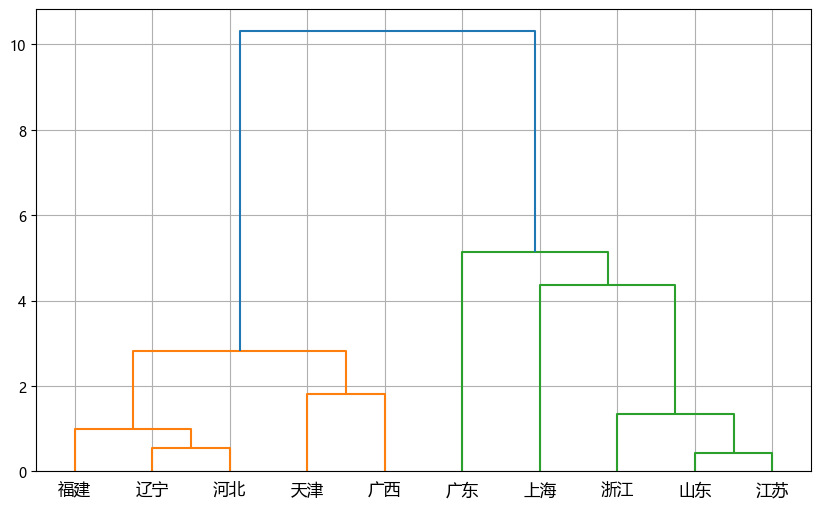

In [8]:
plt.figure(figsize = (10,6))
plt.grid(True)
P = sch.dendrogram(Z,labels = df.AREA.tolist())
plt.show()

#### 3.自动打标签（确定聚类数）

In [9]:
from sklearn.cluster import AgglomerativeClustering
ward = AgglomerativeClustering(n_clusters=4,linkage='ward',compute_full_tree=False)
# compute_full_tree表示省去呈现树形图的操作
ward.fit(df[['Gross','Avg']])
df['cluster'] = ward.labels_
df.sort_values(by = 'cluster')

,AREA,Gross,Avg,cluster
0,辽宁,-1.174241,-0.364178,0
2,河北,-1.399899,-0.870629,0
3,天津,-3.265185,0.698849,0
7,福建,-2.084500,-0.322173,0
9,广西,-3.433179,-1.105531,0
1,山东,2.095775,-0.654819,1
6,浙江,1.209012,0.048116,1
4,江苏,2.386557,-0.337666,1
8,广东,5.501759,0.105138,2
5,上海,0.163901,2.802894,3


- **聚类结果**：
  - 辽宁、河北、天津、福建、广西 → 类0
  - 山东、江苏、浙江 → 类1
  - 广东 → 类2
  - 上海 → 类3

## 四、聚类模型的评估
### 6.4.1 轮廓系数（Silhouette Coefficient）
- **公式**：
  $$
  S(i) = \frac{b(i)-a(i)}{\max\{a(i),b(i)\}}
  $$
  - $a(i)$：样本 $i$ 与同类其他样本的平均距离。
  - $b(i)$：样本 $i$ 与其他不同类样本的最小平均距离。
- **取值**：$[-1,1]$，越接近1表示聚类效果越好（组内紧凑，组间分离）。
- **阈值**：>0.7 效果好，>0.5 一般，<0.25 较差。

### 6.4.2 平方根标准误差（RMSSTD）
- **公式**：
  $$
  RMSSTD = \sqrt{\frac{\sum_{i=1}^n S_i^2}{p}}
  $$
- **含义**：衡量样本与所属聚类中心的平均距离，**越小表示组内越相似**，聚类效果越好。

### 6.4.3 R方（R²）
- **公式**：
  $$
  R^2 = 1 - \frac{SSB}{SST}
  $$
  - $SSB$：组间平方和
  - $SST$：总平方和
- **含义**：取值 $[0,1]$，越接近1表示**组间差异越大**，聚类效果越好。

### 6.4.4 评估指标的选择
- **轮廓系数**：适合小样本，直观反映聚类质量，但计算量大。
- **R方**：适合解释组间差异，但高维数据下易受噪声影响。
- **RMSSTD**：适合衡量组内紧凑性，计算相对简单。

### 6.5 python实现聚类评估

（1）轮廓系数

In [10]:
from sklearn.metrics import silhouette_score
# 使用轮廓系数评估模型
score = silhouette_score(X = df[['Gross','Avg']],labels = df.cluster,metric = 'euclidean')
print('轮廓系数为：',score)

轮廓系数为： 0.4975286983366399


（2）R方计算

In [12]:
from sklearn.metrics import r2_score
data = pd.read_csv('城市经济.csv')[['Gross','Avg']]

# 层次聚类
model = AgglomerativeClustering(n_clusters=3)
model.fit(data)

# 计算R方
labels = model.labels_
centers = np.zeros((3,data.shape[1]))
for i in range(3):
    centers[i] = np.mean(data[labels == i], axis = 0)
r2 = r2_score(data,centers[labels])

print('R方：',r2)

R方： 0.523022635742215


(3)平方根标准差

In [16]:
# 计算平方根标准误差
from sklearn.metrics import mean_squared_error
import math
rmsstd = mean_squared_error(y_true = data,y_pred = centers[labels])
print('平方根标准误差：',math.sqrt(rmsstd))

平方根标准误差： 0.9168611183784848



## 五、结果分析
- **业务解读**：广东和上海经济特征独特，各自成类；天津与广西被分到同一类，与业务直觉不符，说明聚类结果需结合业务常识校验。
- **核心启示**：算法没有绝对优劣，需结合**业务需求**和**可解释性**选择，避免盲目建模。

---


### 总结：层次聚类全流程
1.  **数据探索**：选择连续变量，标准化处理。
2.  **聚类建模**：用scipy绘制层次树，确定最优聚类数；用sklearn自动打标签。
3.  **模型评估**：通过轮廓系数、R方、RMSSTD等指标评估聚类质量。
4.  **业务解读**：结合业务常识分析聚类结果，验证合理性。